In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import torch 
import seaborn as sns

In [2]:
df = pd.read_csv("09-iris.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df = df.drop(columns="Id")

In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
X = df.drop("Species", axis=1).values
y = df["Species"].values

In [7]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()
y = le.fit_transform(y)


In [10]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # düzenli dağıtmasını sağlar y'ye göre.
)

In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)  # multiclass classificationda y type long olmalı. (cross entropy loss functiondan dolayı)
y_test = torch.tensor(y_test, dtype=torch.long)  # unsqueeze gerektirmez. çünkü hedef boyutu sadece [batch size]

In [14]:
from torch import nn

In [15]:
# aşağıdakini kullanmak yerine, nn.sequential ile daha basit bir kullanım

"""
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(4, 16) # 4 features
        self.layer_2 = nn.Linear(16, 16)
        self.layer_3 = nn.Linear(16, 3)  # 3 classes
        
        self.relu = nn.ReLU() 

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

"""

'\nclass IrisClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.layer_1 = nn.Linear(4, 16) # 4 features\n        self.layer_2 = nn.Linear(16, 16)\n        self.layer_3 = nn.Linear(16, 3)  # 3 classes\n        \n        self.relu = nn.ReLU() \n\n    def forward(self, x):\n        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))\n\n'

In [16]:
class IrisClassifier(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4, 12),
            nn.ReLU(),

            nn.Linear(12, 12),
            nn.ReLU(),

            nn.Linear(12, 3)
        )
    
    def forward(self, x):
        return self.linear_layer_stack(x)

In [17]:
model = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.005)

In [18]:
model(X_test)[:5]

tensor([[-0.0298, -0.4336,  0.0709],
        [ 0.2035, -0.6618, -0.1462],
        [ 0.1275, -0.5234, -0.0327],
        [ 0.1340, -0.5282, -0.0311],
        [-0.0492, -0.4263,  0.0584]], grad_fn=<SliceBackward0>)

In [19]:
y_logits = model(X_test)
y_pred_probs = torch.softmax(y_logits, dim = 1)  # olasılık haline getirdik
y_pred_probs[:5]

tensor([[0.3605, 0.2408, 0.3987],
        [0.4704, 0.1980, 0.3316],
        [0.4213, 0.2197, 0.3589],
        [0.4231, 0.2182, 0.3587],
        [0.3572, 0.2450, 0.3978]], grad_fn=<SliceBackward0>)

In [20]:
!pip install torchmetrics

In [21]:
from torchmetrics.classification import MulticlassAccuracy

• Accuracy • Precision • Recall • F1-score • Confusion Matrix • ROC-AUC • Multi-class, multi-label, binary etc. • GPU comptabile

In [22]:
accuracy = MulticlassAccuracy(num_classes=3)

for example we can write  <br>

- acc = accuracy(preds=pred, target=y_train).item() * 100

rather than <br>

- pred = torch.softmax(logits, dim=1).argmax(dim=1)  <br>
- acc = calculate_accuracy(y_train, pred)

In [23]:
epochs = 300
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.argmax(logits, dim=1)
    acc = accuracy(pred, y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)

        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = accuracy(test_pred, y_test).item() * 100

    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch}, Loss: {test_loss:.2f}, Accuracy: {acc:.2f} -- Test Loss: {test_loss:.2f}, Test Accuracy: {test_acc:.2f}")



Epoch: 0, Loss: 1.21, Accuracy: 0.00 -- Test Loss: 1.21, Test Accuracy: 0.00
Epoch: 20, Loss: 1.05, Accuracy: 33.33 -- Test Loss: 1.05, Test Accuracy: 33.33
Epoch: 40, Loss: 0.88, Accuracy: 49.17 -- Test Loss: 0.88, Test Accuracy: 46.67
Epoch: 60, Loss: 0.57, Accuracy: 67.50 -- Test Loss: 0.57, Test Accuracy: 66.67
Epoch: 80, Loss: 0.43, Accuracy: 87.50 -- Test Loss: 0.43, Test Accuracy: 90.00
Epoch: 100, Loss: 0.30, Accuracy: 97.50 -- Test Loss: 0.30, Test Accuracy: 100.00
Epoch: 120, Loss: 0.17, Accuracy: 97.50 -- Test Loss: 0.17, Test Accuracy: 96.67
Epoch: 140, Loss: 0.11, Accuracy: 97.50 -- Test Loss: 0.11, Test Accuracy: 100.00
Epoch: 160, Loss: 0.08, Accuracy: 98.33 -- Test Loss: 0.08, Test Accuracy: 100.00
Epoch: 180, Loss: 0.07, Accuracy: 98.33 -- Test Loss: 0.07, Test Accuracy: 100.00
Epoch: 200, Loss: 0.06, Accuracy: 98.33 -- Test Loss: 0.06, Test Accuracy: 100.00
Epoch: 220, Loss: 0.06, Accuracy: 98.33 -- Test Loss: 0.06, Test Accuracy: 100.00
Epoch: 240, Loss: 0.05, Accura

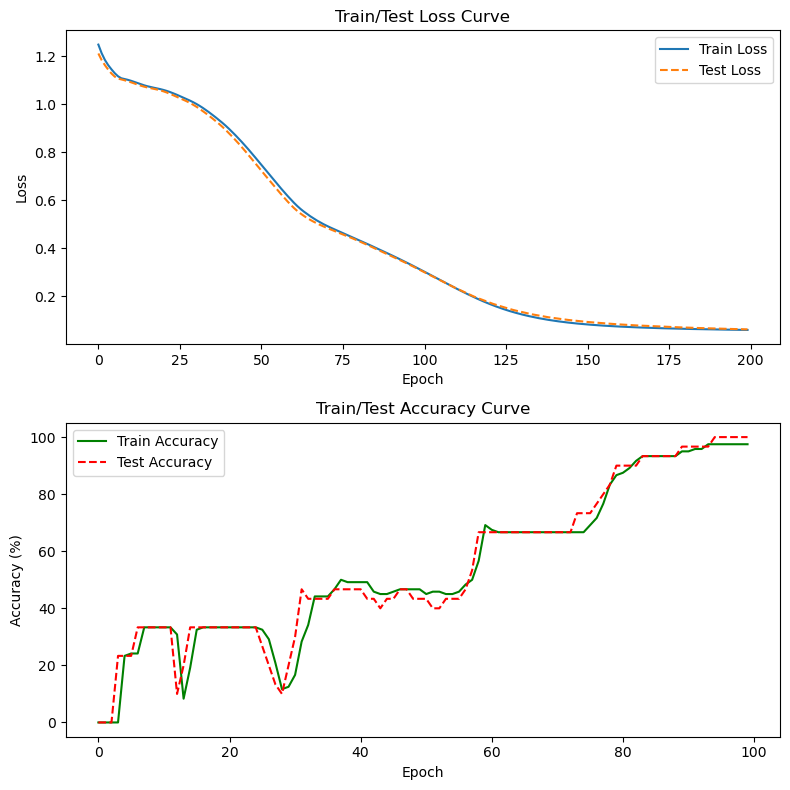

In [24]:
plt.figure(figsize=(8,8))

plt.subplot(2,1,1)
plt.plot(train_losses[:200], label="Train Loss")
plt.plot(test_losses[:200], label="Test Loss", linestyle = "--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")
plt.legend()

plt.subplot(2,1,2)
plt.plot(train_accuracies[:100], label="Train Accuracy", color="green")
plt.plot(test_accuracies[:100], label="Test Accuracy", color="red", linestyle = "--")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [26]:
cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred, y_test)


In [27]:
matrix

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])

In [28]:
from torchmetrics.utilities.plot import plot_confusion_matrix

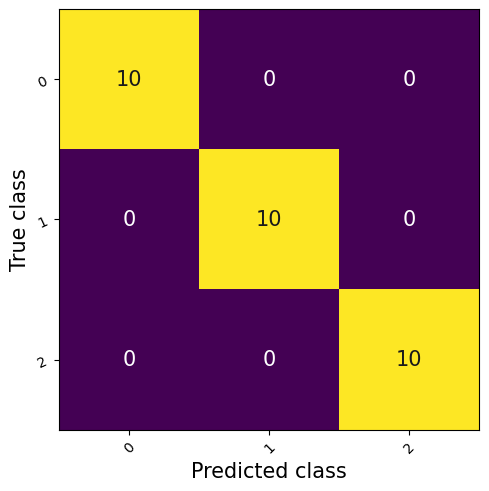

In [29]:
plot_confusion_matrix(matrix)
plt.show()

### Kaydetme

In [30]:
from pathlib import Path

In [ ]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True) 

MODEL_NAME = "iris_classification_model.pth"  # pth uzantısı deep learning modeli oldugunu belirtir
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME   

torch.save(obj = model.state_dict(), f = MODEL_SAVE_PATH)

In [33]:
model.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.4582, -0.4286,  0.5802,  0.5255],
                      [ 0.5940,  0.7228, -0.1583, -0.4972],
                      [-0.4746,  0.1589,  0.2931,  0.1233],
                      [ 0.4517,  0.1234, -0.7408, -0.2036],
                      [-0.3006,  0.3255, -0.1453, -0.3256],
                      [ 0.4239,  0.7279, -0.6674, -0.4059],
                      [ 0.6791,  0.2370, -0.7072, -0.7878],
                      [-0.1403, -0.1146,  0.0565, -0.2064],
                      [-0.4771, -0.3857, -0.4009, -0.0899],
                      [ 0.2830, -0.5462,  0.9634,  0.9276],
                      [ 0.5788,  0.0394, -0.5492, -0.9259],
                      [-0.2838,  0.3790, -0.4719, -0.3466]])),
             ('linear_layer_stack.0.bias',
              tensor([-0.2380,  1.1944,  0.0018, -0.0989,  0.0967,  0.8839,  0.8133, -0.1912,
                       0.2099, -0.7816,  1.3728,  0.2463])),
             ('linear_layer_stack.